# Plant Disease Classification using CNN on Leaf Images
This notebook trains a Convolutional Neural Network (CNN) on a folder of leaf images. The dataset should be organized as:

- dataset/
  - Corn_(maize)___Common_rust_/
  - Potato___Early_blight/
  - Tomato___Bacterial_spot/

Each class folder contains images for that category.

### Goal
- Load images directly from folders
- Train a CNN on leaf images
- Validate the model on a held-out image set
- Save the model and test it on an external image


In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix

print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")
print("Available GPUs:", tf.config.list_physical_devices('GPU'))

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

import kagglehub

# Download latest version
path = kagglehub.dataset_download("shuvranshu/plant-disease-prediction-dataset")

print("Path to dataset files:", path)
# The Kaggle archive contains a parent folder named 'Dataset'
# with the real class folders inside it.
DATASET_DIR = os.path.join(path, "Dataset")
print("Dataset directory:", DATASET_DIR)


TensorFlow Version: 2.21.0
Keras Version: 3.15.1
Available GPUs: []
Path to dataset files: C:\Users\santo\.cache\kagglehub\datasets\shuvranshu\plant-disease-prediction-dataset\versions\1
Dataset directory: C:\Users\santo\.cache\kagglehub\datasets\shuvranshu\plant-disease-prediction-dataset\versions\1\Dataset


In [2]:
# Check if the dataset folder exists before training.
if not os.path.exists(DATASET_DIR):
    raise FileNotFoundError(
        f"Dataset not found at: {DATASET_DIR}\n"
        "Expected structure:\n"
        "path/to/Dataset/Corn_(maize)___Common_rust_/\n"
        "path/to/Dataset/Potato___Early_blight/\n"
        "path/to/Dataset/Tomato___Bacterial_spot/"
    )

for class_name in sorted(os.listdir(DATASET_DIR)):
    class_path = os.path.join(DATASET_DIR, class_name)
    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        print(f"{class_name}: {count} images")


Corn_(maize)___Common_rust_: 300 images
Potato___Early_blight: 300 images
Tomato___Bacterial_spot: 300 images


In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
TARGET_CLASSES = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2,
)

train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    classes=TARGET_CLASSES,
    shuffle=True,
)

val_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    classes=TARGET_CLASSES,
    shuffle=False,
)

print("Classes:", train_generator.class_indices)
print("Training batches:", len(train_generator))
print("Validation batches:", len(val_generator))


Found 720 images belonging to 3 classes.
Found 180 images belonging to 3 classes.
Classes: {'Corn_(maize)___Common_rust_': 0, 'Potato___Early_blight': 1, 'Tomato___Bacterial_spot': 2}
Training batches: 23
Validation batches: 6


In [4]:
input_shape = (*IMG_SIZE, 3)
NUM_CLASSES = len(TARGET_CLASSES)

model = keras.Sequential([
    layers.Input(shape=input_shape),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,664,387 (25.42 MB)

 Trainable params: 6,664,387 (25.42 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator),
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 24s 892ms/step - accuracy: 0.6514 - loss: 0.7905 - val_accuracy: 0.8222 - val_loss: 0.4113
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 812ms/step - accuracy: 0.9167 - loss: 0.2574 - val_accuracy: 0.9556 - val_loss: 0.1213
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 807ms/step - accuracy: 0.9486 - loss: 0.1376 - val_accuracy: 0.9944 - val_loss: 0.0618
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 835ms/step - accuracy: 0.9667 - loss: 0.0983 - val_accuracy: 1.0000 - val_loss: 0.0377
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.9681 - loss: 0.0985 - val_accuracy: 0.9889 - val_loss: 0.0399
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 725ms/step - accuracy: 0.9778 - loss: 0.0684 - val_accuracy: 0.9889 - val_loss: 0.0515
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 733ms/step - accuracy: 0.9847 - loss: 0.0519 - val_accuracy: 1.0000 - val_loss: 0.0128
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 724ms/step - accuracy: 0.9861 - loss: 0.0368 - val_accurac

In [6]:
# Evaluate on validation set
val_loss, val_acc = model.evaluate(val_generator, verbose=0)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc * 100:.2f}%")

class_names = [cls for cls, idx in sorted(train_generator.class_indices.items(), key=lambda item: item[1])]
val_true = val_generator.classes
val_probs = model.predict(val_generator, verbose=0)
val_pred = np.argmax(val_probs, axis=1)

print(f"Accuracy score: {float(np.mean(val_pred == val_true)) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(val_true, val_pred, target_names=class_names, zero_division=0))


Validation Loss: 0.0249
Validation Accuracy: 99.44%
Accuracy score: 100.00%

Classification Report:
                             precision    recall  f1-score   support

Corn_(maize)___Common_rust_       1.00      1.00      1.00        60
      Potato___Early_blight       1.00      1.00      1.00        60
    Tomato___Bacterial_spot       1.00      1.00      1.00        60

                   accuracy                           1.00       180
                  macro avg       1.00      1.00      1.00       180
               weighted avg       1.00      1.00      1.00       180



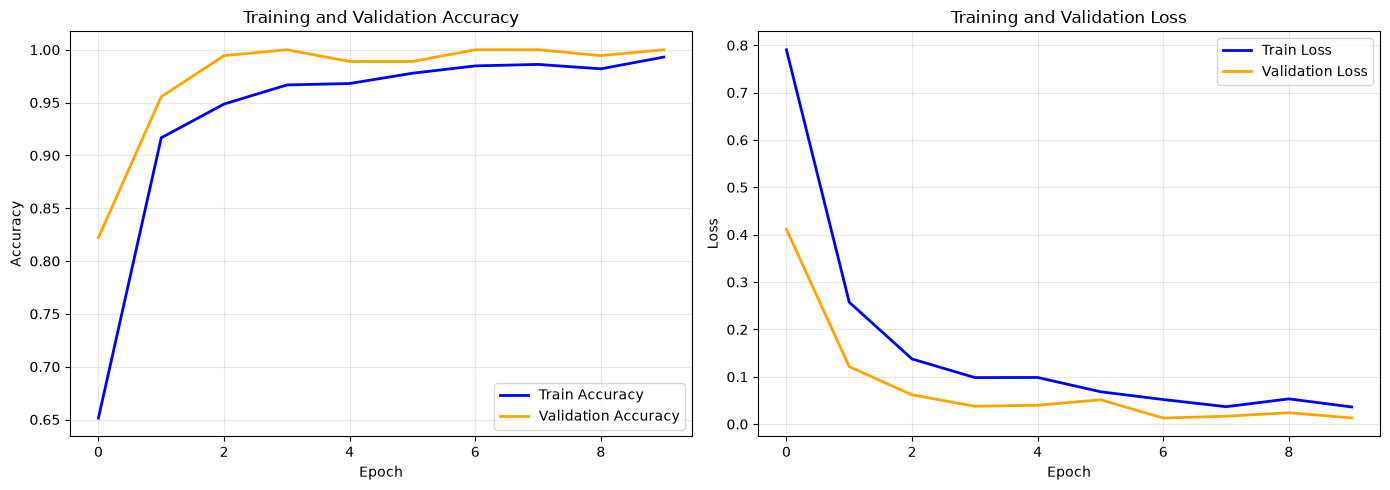

In [7]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_df["accuracy"], label="Train Accuracy", color="blue", linewidth=2)
plt.plot(history_df["val_accuracy"], label="Validation Accuracy", color="orange", linewidth=2)
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["loss"], label="Train Loss", color="blue", linewidth=2)
plt.plot(history_df["val_loss"], label="Validation Loss", color="orange", linewidth=2)
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


d:\Projects\Dp Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


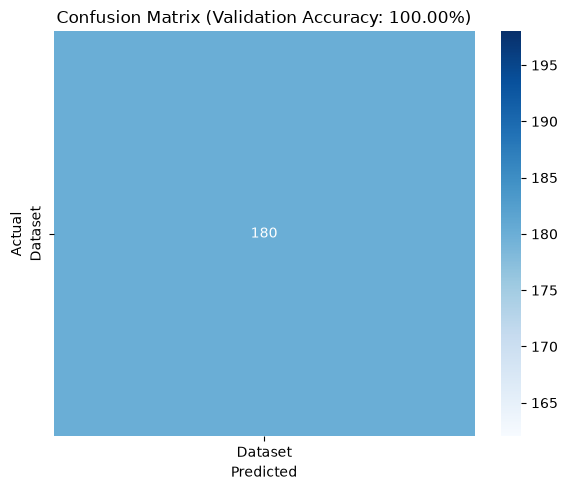


Confusion Matrix:
[[180]]


In [22]:
class_names = [cls for cls, idx in sorted(train_generator.class_indices.items(), key=lambda item: item[1])]
cm = confusion_matrix(val_true, val_pred, labels=list(range(len(class_names))))
plt.figure(figsize=(6, 5))
sns = None
try:
    import seaborn as sns
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
except Exception:
    plt.imshow(cm, cmap='Blues')
    plt.xticks(range(len(class_names)), class_names)
    plt.yticks(range(len(class_names)), class_names)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

plt.title(f"Confusion Matrix (Validation Accuracy: {val_acc * 100:.2f}%)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("\nConfusion Matrix:")
print(cm)


In [8]:
MODEL_PATH = r"d:\Projects\Dp Learning\CNN\Classification\plant_disease_cnn_model.keras"
model.save(MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")



Model saved to: d:\Projects\Dp Learning\CNN\Classification\plant_disease_cnn_model.keras


Actual class: Corn_(maize)___Common_rust_
Predicted class: Corn_(maize)___Common_rust_
Prediction probabilities: [9.9976808e-01 2.3193863e-04 8.5573666e-11]


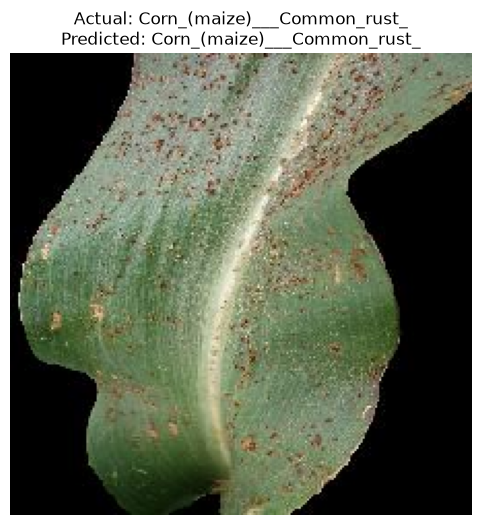

In [9]:
# Show one actual validation image with actual vs predicted class
import random
from tensorflow.keras.preprocessing import image as keras_image

class_names = [cls for cls, idx in sorted(train_generator.class_indices.items(), key=lambda item: item[1])]

# Pick one random validation image
sample_index = random.randint(0, len(val_generator.filenames) - 1)

image_path = os.path.join(DATASET_DIR, val_generator.filenames[sample_index])
true_class_index = val_generator.labels[sample_index]
true_class_name = class_names[true_class_index]

img = keras_image.load_img(image_path, target_size=IMG_SIZE)
img_array = keras_image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

pred_probs = model.predict(img_array, verbose=0)[0]
pred_class_index = int(np.argmax(pred_probs))
pred_class_name = class_names[pred_class_index]

print(f"Actual class: {true_class_name}")
print(f"Predicted class: {pred_class_name}")
print(f"Prediction probabilities: {pred_probs}")

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Actual: {true_class_name}\nPredicted: {pred_class_name}")
plt.axis("off")
plt.show()

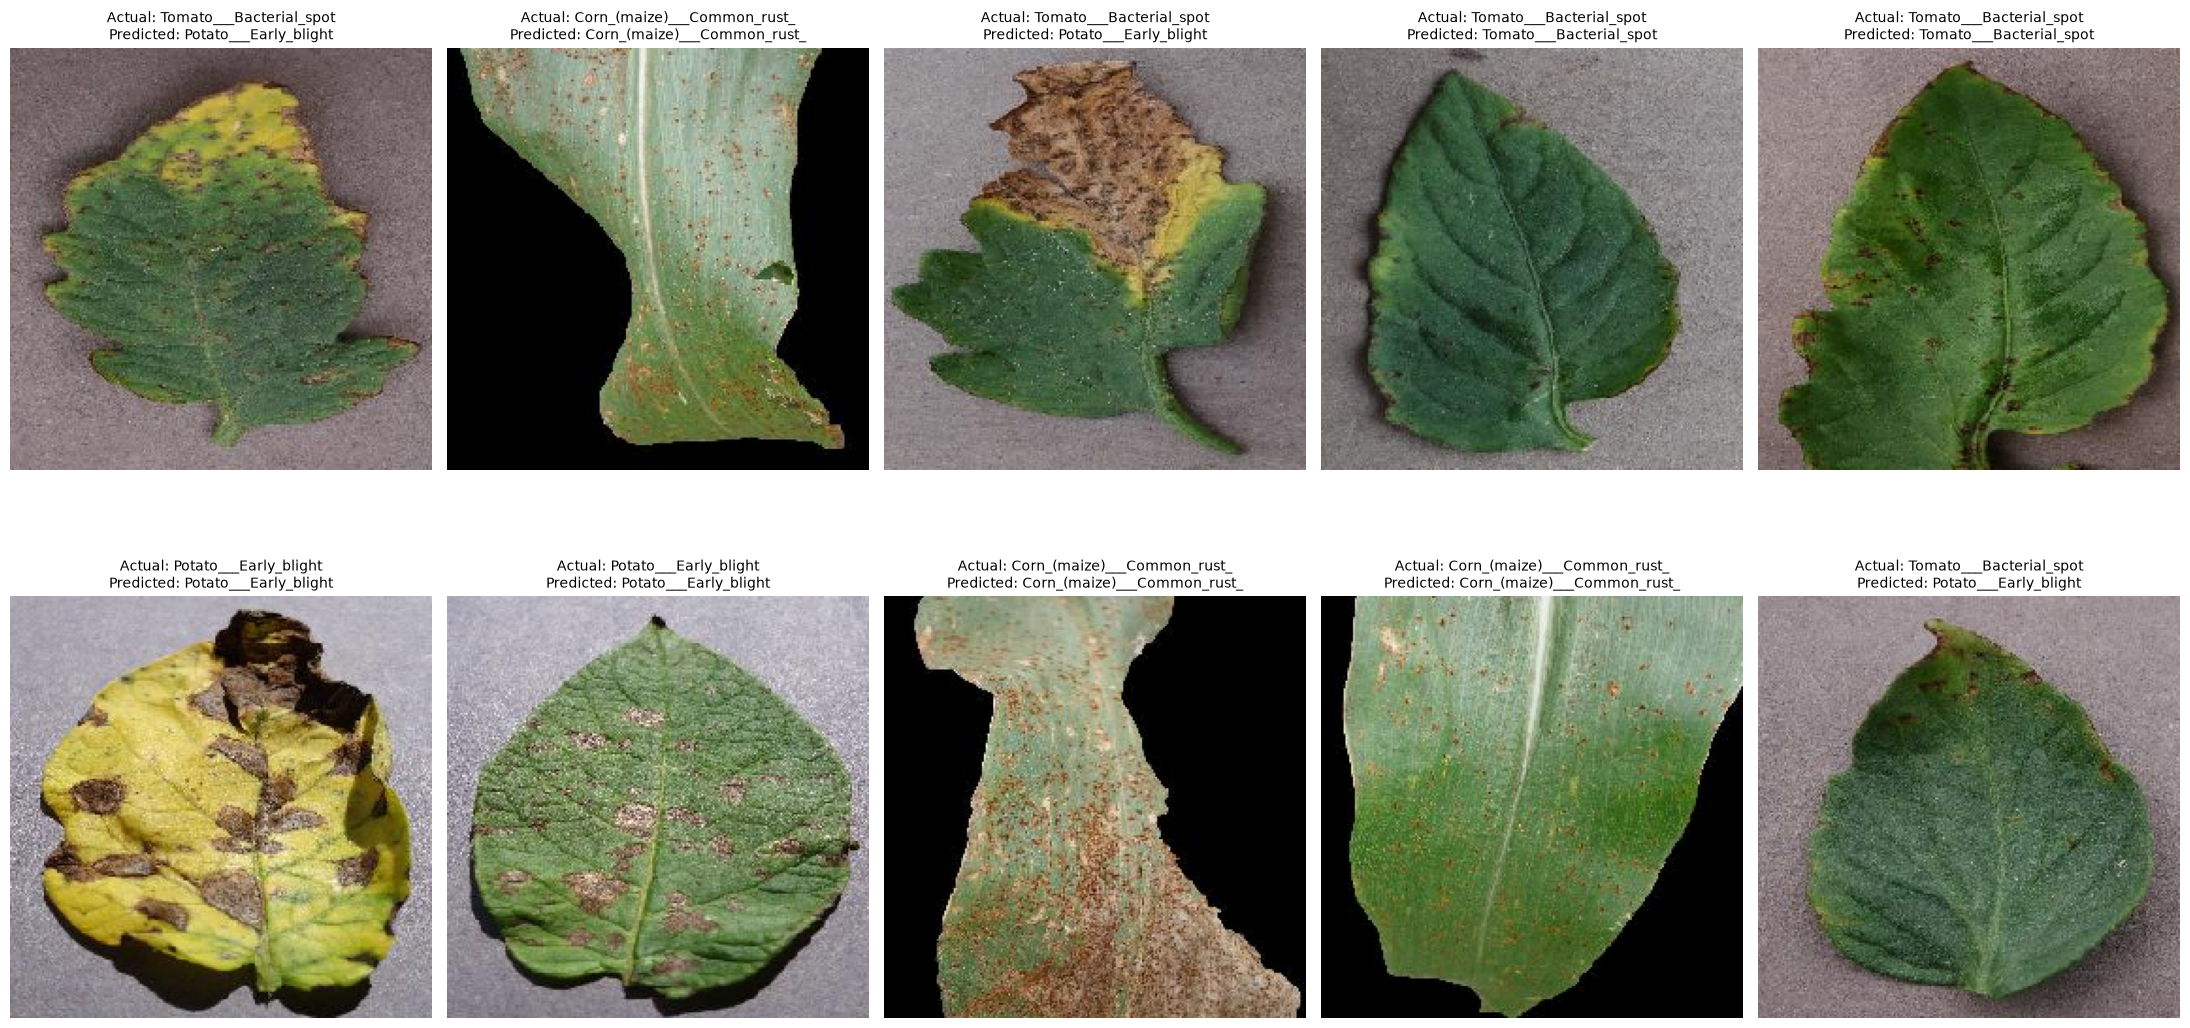

In [10]:
# Show 10 random validation images with larger display and actual/predicted class
import random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image as keras_image

class_names = [cls for cls, idx in sorted(train_generator.class_indices.items(), key=lambda item: item[1])]
sample_indices = random.sample(range(len(val_generator.filenames)), 10)

fig, axes = plt.subplots(2, 5, figsize=(22, 12))
axes = axes.flatten()

for ax, idx in zip(axes, sample_indices):
    image_rel_path = val_generator.filenames[idx]
    image_abs_path = os.path.join(DATASET_DIR, image_rel_path)
    true_class_index = val_generator.labels[idx]
    true_class_name = class_names[true_class_index]

    img = keras_image.load_img(image_abs_path, target_size=IMG_SIZE)
    img_array = keras_image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred_probs = model.predict(img_array, verbose=0)[0]
    pred_class_index = int(np.argmax(pred_probs))
    pred_class_name = class_names[pred_class_index]

    ax.imshow(img)
    ax.set_title(f"Actual: {true_class_name}\nPredicted: {pred_class_name}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [11]:
# Test the model on a single external image
from tensorflow.keras.preprocessing import image as keras_image

TEST_IMAGE_PATH = r"d:\Projects\Dp Learning\leaf_test_image.jpg"
class_names = [cls for cls, idx in sorted(train_generator.class_indices.items(), key=lambda item: item[1])]

if os.path.exists(TEST_IMAGE_PATH):
    img = keras_image.load_img(TEST_IMAGE_PATH, target_size=IMG_SIZE)
    img_array = keras_image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred_probs = model.predict(img_array, verbose=0)[0]
    pred_class_index = int(np.argmax(pred_probs))
    pred_label = class_names[pred_class_index]
    pred_confidence = float(pred_probs[pred_class_index])

    print("Predicted class index:", pred_class_index)
    print("Predicted probability:", pred_probs)
    print("Predicted label:", pred_label)
    plt.imshow(img)
    plt.title(f"Prediction: {pred_label} ({pred_confidence:.3f})")
    plt.axis('off')
    plt.show()
else:

    print(f"External test image not found at: {TEST_IMAGE_PATH}")
    print("Add your leaf image there and run this cell again.")

External test image not found at: d:\Projects\Dp Learning\leaf_test_image.jpg
Add your leaf image there and run this cell again.
